# Pure-space two-scale Column Vecchia diagnostic, separated range grid, fixed positive nugget

This notebook tests a multiscale spatial covariance without making all two-Matern parameters free.

For each hour and resolution, it grid-searches fixed `(range_short, range_long)` pairs with an explicit separation constraint and estimates only two variance weights:

```text
Cov(h) = sigmasq_short * Matern(h; range_short, smooth_short)
       + sigmasq_long  * Matern(h; range_long,  smooth_long)
       + nugget_fixed
```

Default diagnostic:

- Column reverse-L pure-space geometry: `Up2_Right3_M10`, real source coordinates for covariance
- each time slot fitted independently
- `x8, x4, x2, x1` regular-grid thinning
- `nugget_fixed = 2.0`
- `smooth_short = smooth_long = 0.5`
- `range_long >= 3 * range_short`
- estimate only `sigmasq_short`, `sigmasq_long`

Interpretation target:

- If fine resolution prefers larger `sigmasq_short` or smaller selected `range_short`, that supports multiscale/fine-scale structure.
- If best range pair and variance split are stable across resolution, single-scale misspecification is less likely.

This `sep3` version is meant to avoid ambiguous pairs such as `(0.12, 0.18)`, where the two components are too close to interpret as separate scales.


This `nug2` version keeps `smooth_short = smooth_long = 0.5` and fixes a positive nugget to test whether the previous short-scale component was absorbing nugget-like unresolved variability.


In [1]:
import gc
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

LOCAL_SRC = '/Users/joonwonlee/Documents/GEMS_TCO-1/src'
AMAREL_SRC = '/home/jl2815/tco'
SRC = AMAREL_SRC if Path(AMAREL_SRC).exists() else LOCAL_SRC
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed
from GEMS_TCO.kernels_space_multiscale_050826 import ColumnSpaceTwoScaleFixedRangeTrendVecchiaFit

DEVICE = torch.device('cpu')
DTYPE = torch.float64
ROUND_DECIMALS = 4

pd.set_option('display.max_columns', 160)
pd.set_option('display.width', 220)
print('SRC:', SRC)
print('device:', DEVICE)

SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
device: cpu


In [2]:
# Experiment config
YEAR = '2024'
MONTH = 7
DAY_IDX = 2                 # 0-based: 2 -> 2024-07-03
HOUR_IDX_LIST = list(range(8))
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]

RESOLUTION_STRIDES = [8, 4, 2, 1]
MEAN_DESIGN = 'latlon'

# Finer short-range grid plus explicit scale separation.
# This avoids treating close pairs such as 0.12 vs 0.18 as two distinct scales.
RANGE_SHORT_GRID = [0.015, 0.025, 0.035, 0.050, 0.070]
RANGE_LONG_GRID = [0.150, 0.250, 0.400, 0.700]
MIN_RANGE_RATIO = 3.0
NUGGET_FIXED = 2.0
SMOOTH_SHORT = 0.5
SMOOTH_LONG = 0.5
MODEL_SMOOTH_FOR_CLASS = 0.5

COLUMN_SPEC = {
    'model': 'ColumnSpaceTwoScaleFixedRange_Up2_Right3_M10_realloc',
    'head_right_cols': 0,
    'above_count': 2,
    'right_col_count': 3,
    'per_time_conditioning_count': 8,
    'target_chunk_size': 512,
}

LBFGS_LR = 1.0
LBFGS_STEPS = 6
LBFGS_EVAL = 18
LBFGS_HIST = 10
GRAD_TOL = 1e-5

INIT_SIGMASQ_SHORT = 3.0
INIT_SIGMASQ_LONG = 10.0

PURE_SPACE_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space')
OUT_DIR = PURE_SPACE_DIR / 'log'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PREFIX = 'real_pure_space_multiscale_column_rangegrid_sep3_nug2_050826'

range_pairs = [(rs, rl) for rs in RANGE_SHORT_GRID for rl in RANGE_LONG_GRID if rl >= MIN_RANGE_RATIO * rs]
print('day:', f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}')
print('hours:', HOUR_IDX_LIST)
print('strides:', RESOLUTION_STRIDES)
print('range pairs:', range_pairs)
print('n range pairs:', len(range_pairs), '| min long/short ratio:', MIN_RANGE_RATIO)
print('nugget_fixed:', NUGGET_FIXED, 'smooth_short/long:', SMOOTH_SHORT, SMOOTH_LONG)

day: 20240703
hours: [0, 1, 2, 3, 4, 5, 6, 7]
strides: [8, 4, 2, 1]
range pairs: [(0.015, 0.15), (0.015, 0.25), (0.015, 0.4), (0.015, 0.7), (0.025, 0.15), (0.025, 0.25), (0.025, 0.4), (0.025, 0.7), (0.035, 0.15), (0.035, 0.25), (0.035, 0.4), (0.035, 0.7), (0.05, 0.25), (0.05, 0.4), (0.05, 0.7), (0.07, 0.25), (0.07, 0.4), (0.07, 0.7)]
n range pairs: 18 | min long/short ratio: 3.0
nugget_fixed: 2.0 smooth_short/long: 0.5 0.5


In [3]:
def make_sigma_params(sig_short=INIT_SIGMASQ_SHORT, sig_long=INIT_SIGMASQ_LONG):
    return [
        torch.tensor([np.log(sig_short)], device=DEVICE, dtype=DTYPE, requires_grad=True),
        torch.tensor([np.log(sig_long)], device=DEVICE, dtype=DTYPE, requires_grad=True),
    ]


def backmap_two(raw, range_short, range_long):
    sig_short = float(np.exp(raw[0]))
    sig_long = float(np.exp(raw[1]))
    total = sig_short + sig_long
    return {
        'sigmasq_short': sig_short,
        'sigmasq_long': sig_long,
        'sigmasq_total': total,
        'short_fraction': sig_short / total if total > 0 else np.nan,
        'range_short': float(range_short),
        'range_long': float(range_long),
        'nugget': float(NUGGET_FIXED),
    }


def count_valid(input_map):
    return int(sum(((~torch.isnan(v[:, 2])) & (~torch.isnan(v[:, 0])) & (~torch.isnan(v[:, 1]))).sum().item() for v in input_map.values()))


def space_diag(model):
    groups = getattr(model, 'Batched_Groups', []) or []
    if not groups:
        return {'n_batches': 0, 'n_tails': 0, 'mean_m': 0.0, 'max_m': 0, 'largest_batch_n': 0}
    ns = np.asarray([int(g['target_idx'].shape[0]) for g in groups], dtype=np.int64)
    ms = np.asarray([int(g['max_m']) for g in groups], dtype=np.int64)
    return {
        'n_batches': int(len(groups)),
        'n_tails': int(ns.sum()),
        'mean_m': float(ms.mean()),
        'max_m': int(ms.max()),
        'largest_batch_n': int(ns.max()),
    }


def round_df(df, digits=ROUND_DECIMALS):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)
    return out


def empty_cache():
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


def resolution_label(stride):
    return f'x{int(stride)}'

In [4]:
loader = load_data_dynamic_processed(config.mac_data_load_path)
df_map, _, _, monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
    lat_lon_resolution=[1, 1],
    mm_cond_number=10,
    years_=[YEAR],
    months_=[MONTH],
    lat_range=LAT_RANGE,
    lon_range=LON_RANGE,
    is_whittle=True,
)
month_keys = sorted(df_map.keys())
day_keys = month_keys[DAY_IDX * 8:(DAY_IDX + 1) * 8]
if len(day_keys) != 8:
    raise ValueError(f'Day {DAY_IDX} has {len(day_keys)} slices, expected 8')

first_df = df_map[day_keys[0]].reset_index(drop=True)
grid_order = (
    first_df
    .assign(_orig_idx=np.arange(len(first_df)))
    .sort_values(['Longitude', 'Latitude', '_orig_idx'], kind='mergesort')['_orig_idx']
    .to_numpy(dtype=np.int64)
)
grid_coords_full = first_df.iloc[grid_order][['Latitude', 'Longitude']].to_numpy(dtype=np.float64)

print('monthly_mean:', round(monthly_mean, 4))
print('day keys:', day_keys[0], '...', day_keys[-1])
print('full grid:', grid_coords_full.shape)
print('unique lat/lon:', len(np.unique(np.round(grid_coords_full[:,0], 6))), len(np.unique(np.round(grid_coords_full[:,1], 6))))

--- Global Monthly Mean for 2024-7: 257.9726 ---
monthly_mean: 257.9726
day keys: 2024_07_y24m07day03_hm00:53 ... 2024_07_y24m07day03_hm07:48
full grid: (18126, 2)
unique lat/lon: 114 159


In [5]:
def load_hour_map(hour_idx):
    key = day_keys[int(hour_idx)]
    hour_df_map = {key: df_map[key]}
    hour_map, _ = loader.load_working_data(
        hour_df_map,
        monthly_mean=monthly_mean,
        idx_for_datamap=[0, 1],
        ord_mm=grid_order,
        dtype=DTYPE,
        keep_ori=True,
    )
    return {k: v.to(DEVICE) for k, v in hour_map.items()}, key


def thin_hour_map(hour_map, stride):
    n_full = grid_coords_full.shape[0]
    thin_idx = np.arange(0, n_full, int(stride), dtype=np.int64)
    thin_map = {k: v[thin_idx].contiguous() for k, v in hour_map.items()}
    thin_grid = np.ascontiguousarray(grid_coords_full[thin_idx])
    return thin_map, thin_grid, thin_idx


def build_model(input_map, grid_coords, range_short, range_long):
    return ColumnSpaceTwoScaleFixedRangeTrendVecchiaFit(
        smooth=MODEL_SMOOTH_FOR_CLASS,
        input_map=input_map,
        grid_coords=grid_coords,
        head_right_cols=COLUMN_SPEC['head_right_cols'],
        above_count=COLUMN_SPEC['above_count'],
        right_col_count=COLUMN_SPEC['right_col_count'],
        per_time_conditioning_count=COLUMN_SPEC['per_time_conditioning_count'],
        target_chunk_size=COLUMN_SPEC['target_chunk_size'],
        range_short=range_short,
        range_long=range_long,
        nugget_fixed=NUGGET_FIXED,
        smooth_short=SMOOTH_SHORT,
        smooth_long=SMOOTH_LONG,
        mean_design=MEAN_DESIGN,
    )


def make_row(hour_idx, time_key, stride, range_short, range_long, n_grid, n_valid, pre_s, fit_s, loss, fit_iter, est, diag):
    return {
        'date_str': f'{YEAR}{MONTH:02d}{DAY_IDX + 1:02d}',
        'day_idx': DAY_IDX,
        'hour_idx': int(hour_idx),
        'time_key': str(time_key),
        'resolution_stride': int(stride),
        'resolution_label': resolution_label(stride),
        'mean_design': MEAN_DESIGN,
        'model': COLUMN_SPEC['model'],
        'kernel': 'column_space_twoscale_fixedrange_tonly_realloc',
        'coord_mode': 'regular-grid every-k thinning; covariance on Source_Latitude/Source_Longitude',
        'smooth_short': float(SMOOTH_SHORT),
        'smooth_long': float(SMOOTH_LONG),
        'range_short_fixed': float(range_short),
        'range_long_fixed': float(range_long),
        'nugget_fixed': float(NUGGET_FIXED),
        'loss': float(loss),
        'fit_iter_raw': int(fit_iter),
        'fit_steps_reported': int(fit_iter) + 1,
        'precompute_s': float(pre_s),
        'fit_s': float(fit_s),
        'total_s': float(pre_s + fit_s),
        'n_grid': int(n_grid),
        'n_valid': int(n_valid),
        'valid_fraction': float(n_valid / n_grid) if n_grid else np.nan,
        **{f'est_{k}': v for k, v in est.items()},
        **diag,
        'total_conditioning_nominal': COLUMN_SPEC['per_time_conditioning_count'],
        'head_right_cols': COLUMN_SPEC['head_right_cols'],
        'above_count': COLUMN_SPEC['above_count'],
        'right_col_count': COLUMN_SPEC['right_col_count'],
        'per_time_conditioning_count': COLUMN_SPEC['per_time_conditioning_count'],
    }

In [6]:
def fit_range_pair(hour_idx, stride, range_short, range_long):
    hour_map, time_key = load_hour_map(hour_idx)
    thin_map, thin_grid, _ = thin_hour_map(hour_map, stride)
    n_grid = int(thin_grid.shape[0])
    n_valid = count_valid(thin_map)
    print('\n' + '=' * 100)
    print(
        f'TWO-SCALE | h{hour_idx + 1} | {time_key} | {resolution_label(stride)} | '
        f'rs={range_short:.3f}, rl={range_long:.3f} | n_valid={n_valid:,}'
    )

    model = build_model(thin_map, thin_grid, range_short, range_long)
    t_pre = time.time()
    model.precompute_conditioning_sets()
    pre_s = time.time() - t_pre
    diag = space_diag(model)

    params = make_sigma_params()
    opt = model.set_optimizer(params, lr=LBFGS_LR, max_iter=LBFGS_EVAL, max_eval=LBFGS_EVAL, history_size=LBFGS_HIST)
    t_fit = time.time()
    out, fit_iter = model.fit_vecc_lbfgs(params, opt, max_steps=LBFGS_STEPS, grad_tol=GRAD_TOL)
    fit_s = time.time() - t_fit
    est = backmap_two(out[:2], range_short, range_long)
    row = make_row(hour_idx, time_key, stride, range_short, range_long, n_grid, n_valid, pre_s, fit_s, out[-1], fit_iter, est, diag)
    print('RESULT:', {k: round(v, 4) if isinstance(v, float) else v for k, v in row.items() if k in ['resolution_label','loss','est_sigmasq_short','est_sigmasq_long','est_short_fraction','est_sigmasq_total']})

    del model, params, opt, hour_map, thin_map
    empty_cache()
    return row

In [7]:
rows = []
for hour_idx in HOUR_IDX_LIST:
    for stride in RESOLUTION_STRIDES:
        for range_short, range_long in range_pairs:
            rows.append(fit_range_pair(hour_idx, stride, range_short, range_long))
            tmp = round_df(pd.DataFrame(rows))
            tmp.to_csv(OUT_DIR / f'{OUT_PREFIX}_all.csv', index=False, float_format=f'%.{ROUND_DECIMALS}f')

all_df = pd.DataFrame(rows)
all_path = OUT_DIR / f'{OUT_PREFIX}_all.csv'
round_df(all_df).to_csv(all_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved all grid results:', all_path)
display(round_df(all_df))


TWO-SCALE | h1 | 2024_07_y24m07day03_hm00:53 | x8 | rs=0.015, rl=0.150 | n_valid=2,259
Pre-computing ColumnSpaceVecchia [head_right=0, above=2, right_cols=3, m=8]... Done in 0.0s. grid=57x159, heads=0, tails=2259, m mean/med/max=7.2/8/8
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/6 / Loss: 1.660055 / Max Grad: 4.49e-06 ---
Converged: max_grad 4.49e-06 < 1.00e-05
Final Pure-Space Params: {'sigmasq_short': 0.0010319572105111873, 'sigmasq_long': 9.4893177291267, 'sigmasq_total': 9.490349686337211, 'range_short': 0.015, 'range_long': 0.15, 'nugget': 2.0}
RESULT: {'resolution_label': 'x8', 'loss': 1.6601, 'est_sigmasq_short': 0.001, 'est_sigmasq_long': 9.4893, 'est_sigmasq_total': 9.4903, 'est_short_fraction': 0.0001}

TWO-SCALE | h1 | 2024_07_y24m07day03_hm00:53 | x8 | rs=0.015, rl=0.250 | n_valid=2,259
Pre-computing ColumnSpaceVecchia [head_right=0, above=2, right_cols=3, m=8]... Done in 0.0s. grid=57x159, heads=0, tails=2259, m mean/med/max=7.2/8/8
--- Starting Pure-Space Vecc

,date_str,day_idx,hour_idx,time_key,resolution_stride,resolution_label,mean_design,model,kernel,coord_mode,smooth_short,smooth_long,range_short_fixed,range_long_fixed,nugget_fixed,loss,fit_iter_raw,fit_steps_reported,precompute_s,fit_s,total_s,n_grid,n_valid,valid_fraction,est_sigmasq_short,est_sigmasq_long,est_sigmasq_total,est_short_fraction,est_range_short,est_range_long,est_nugget,n_batches,n_tails,mean_m,max_m,largest_batch_n,total_conditioning_nominal,head_right_cols,above_count,right_col_count,per_time_conditioning_count
0,20240703,2,0,2024_07_y24m07day03_hm00:53,8,x8,latlon,ColumnSpaceTwoScaleFixedRange_Up2_Right3_M10_r...,column_space_twoscale_fixedrange_tonly_realloc,regular-grid every-k thinning; covariance on S...,0.5,0.5,0.015,0.15,2.0,1.6601,0,1,0.0389,0.1674,0.2064,2266,2259,0.9969,0.0010,9.4893,9.4903,0.0001,0.015,0.15,2.0,1,2259,8.0,8,2259,8,0,2,3,8
1,20240703,2,0,2024_07_y24m07day03_hm00:53,8,x8,latlon,ColumnSpaceTwoScaleFixedRange_Up2_Right3_M10_r...,column_space_twoscale_fixedrange_tonly_realloc,regular-grid every-k thinning; covariance on S...,0.5,0.5,0.015,0.25,2.0,1.6255,0,1,0.0372,0.0961,0.1333,2266,2259,0.9969,0.9277,9.1748,10.1025,0.0918,0.015,0.25,2.0,1,2259,8.0,8,2259,8,0,2,3,8
2,20240703,2,0,2024_07_y24m07day03_hm00:53,8,x8,latlon,ColumnSpaceTwoScaleFixedRange_Up2_Right3_M10_r...,column_space_twoscale_fixedrange_tonly_realloc,regular-grid every-k thinning; covariance on S...,0.5,0.5,0.015,0.40,2.0,1.6069,0,1,0.0392,0.0755,0.1147,2266,2259,0.9969,2.0531,8.6097,10.6628,0.1925,0.015,0.40,2.0,1,2259,8.0,8,2259,8,0,2,3,8
3,20240703,2,0,2024_07_y24m07day03_hm00:53,8,x8,latlon,ColumnSpaceTwoScaleFixedRange_Up2_Right3_M10_r...,column_space_twoscale_fixedrange_tonly_realloc,regular-grid every-k thinning; covariance on S...,0.5,0.5,0.015,0.70,2.0,1.6004,0,1,0.0376,0.0656,0.1032,2266,2259,0.9969,2.8939,9.0825,11.9764,0.2416,0.015,0.70,2.0,1,2259,8.0,8,2259,8,0,2,3,8
4,20240703,2,0,2024_07_y24m07day03_hm00:53,8,x8,latlon,ColumnSpaceTwoScaleFixedRange_Up2_Right3_M10_r...,column_space_twoscale_fixedrange_tonly_realloc,regular-grid every-k thinning; covariance on S...,0.5,0.5,0.025,0.15,2.0,1.6251,1,2,0.0374,0.2376,0.2750,2266,2259,0.9969,0.0003,9.4905,9.4908,0.0000,0.025,0.15,2.0,1,2259,8.0,8,2259,8,0,2,3,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,20240703,2,7,2024_07_y24m07day03_hm07:48,1,x1,latlon,ColumnSpaceTwoScaleFixedRange_Up2_Right3_M10_r...,column_space_twoscale_fixedrange_tonly_realloc,regular-grid every-k thinning; covariance on S...,0.5,0.5,0.050,0.40,2.0,1.4050,0,1,0.8006,0.5597,1.3602,18126,18102,0.9987,2.2071,12.2510,14.4581,0.1527,0.050,0.40,2.0,1,18102,8.0,8,18102,8,0,2,3,8
572,20240703,2,7,2024_07_y24m07day03_hm07:48,1,x1,latlon,ColumnSpaceTwoScaleFixedRange_Up2_Right3_M10_r...,column_space_twoscale_fixedrange_tonly_realloc,regular-grid every-k thinning; covariance on S...,0.5,0.5,0.050,0.70,2.0,1.4078,0,1,0.7987,0.6270,1.4257,18126,18102,0.9987,2.7721,16.0015,18.7736,0.1477,0.050,0.70,2.0,1,18102,8.0,8,18102,8,0,2,3,8
573,20240703,2,7,2024_07_y24m07day03_hm07:48,1,x1,latlon,ColumnSpaceTwoScaleFixedRange_Up2_Right3_M10_r...,column_space_twoscale_fixedrange_tonly_realloc,regular-grid every-k thinning; covariance on S...,0.5,0.5,0.070,0.25,2.0,1.4059,0,1,0.8001,0.5627,1.3628,18126,18102,0.9987,1.9382,10.0772,12.0154,0.1613,0.070,0.25,2.0,1,18102,8.0,8,18102,8,0,2,3,8
574,20240703,2,7,2024_07_y24m07day03_hm07:48,1,x1,latlon,ColumnSpaceTwoScaleFixedRange_Up2_Right3_M10_r...,column_space_twoscale_fixedrange_tonly_realloc,regular-grid every-k thinning; covariance on S...,0.5,0.5,0.070,0.40,2.0,1.4033,0,1,0.7992,0.4761,1.2753,18126,18102,0.9987,3.3171,9.6649,12.9819,0.2555,0.070,0.40,2.0,1,18102,8.0,8,18102,8,0,2,3,8


In [8]:
# Best range pair by hour and resolution.
if 'all_df' not in globals() or all_df.empty:
    all_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_all.csv')

idx = all_df.groupby(['hour_idx', 'resolution_stride'])['loss'].idxmin()
best_df = all_df.loc[idx].copy().sort_values(['hour_idx', 'resolution_stride'])
best_path = OUT_DIR / f'{OUT_PREFIX}_best_by_hour_resolution.csv'
round_df(best_df).to_csv(best_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved best table:', best_path)

display_cols = [
    'hour_idx', 'resolution_stride', 'resolution_label', 'loss',
    'range_short_fixed', 'range_long_fixed',
    'est_sigmasq_short', 'est_sigmasq_long', 'est_sigmasq_total', 'est_short_fraction',
    'n_grid', 'n_valid', 'total_s'
]
display(round_df(best_df[display_cols]))

Saved best table: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_multiscale_column_rangegrid_sep3_nug2_050826_best_by_hour_resolution.csv


,hour_idx,resolution_stride,resolution_label,loss,range_short_fixed,range_long_fixed,est_sigmasq_short,est_sigmasq_long,est_sigmasq_total,est_short_fraction,n_grid,n_valid,total_s
65,0,1,x1,1.4119,0.035,0.70,2.7652,11.6976,14.4628,0.1912,18126,18067,1.2612
46,0,2,x2,1.5347,0.035,0.40,3.2709,9.3292,12.6001,0.2596,9063,9033,0.4672
35,0,4,x4,1.4876,0.070,0.70,2.9960,8.7218,11.7178,0.2557,4532,4518,0.1909
14,0,8,x8,1.5997,0.050,0.70,3.3697,8.1495,11.5192,0.2925,2266,2259,0.1045
143,1,1,x1,1.3558,0.070,0.70,3.1454,10.9551,14.1006,0.2231,18126,17670,1.3075
125,1,2,x2,1.4145,0.070,0.70,2.7973,12.1070,14.9043,0.1877,9063,8840,0.4929
91,1,4,x4,1.5179,0.015,0.25,0.0000,10.9795,10.9795,0.0000,4532,4422,0.5168
88,1,8,x8,1.6447,0.070,0.40,2.5306,10.0303,12.5608,0.2015,2266,2208,0.0943
213,2,1,x1,1.3600,0.070,0.25,0.0002,13.3024,13.3026,0.0000,18126,16698,2.1862
192,2,2,x2,1.4618,0.050,0.25,0.1385,13.1848,13.3233,0.0104,9063,8353,0.8318


In [9]:
# Compact stability diagnostics for the selected range pairs.
# A good multiscale explanation should not only lower loss; it should also choose separated
# range pairs and variance fractions with some stability across resolution.
if 'best_df' not in globals() or best_df.empty:
    best_df = pd.read_csv(OUT_DIR / f'{OUT_PREFIX}_best_by_hour_resolution.csv')

stability = (
    best_df
    .groupby('resolution_label')
    .agg(
        loss_mean=('loss', 'mean'),
        loss_sd=('loss', 'std'),
        range_short_median=('range_short_fixed', 'median'),
        range_long_median=('range_long_fixed', 'median'),
        short_fraction_mean=('est_short_fraction', 'mean'),
        short_fraction_sd=('est_short_fraction', 'std'),
        sigmasq_total_mean=('est_sigmasq_total', 'mean'),
    )
    .reset_index()
)
stability['resolution_label'] = pd.Categorical(
    stability['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)
stability = stability.sort_values('resolution_label')
stability_path = OUT_DIR / f'{OUT_PREFIX}_stability_by_resolution.csv'
round_df(stability).to_csv(stability_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
print('Saved stability table:', stability_path)
display(round_df(stability))


Saved stability table: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_multiscale_column_rangegrid_sep3_nug2_050826_stability_by_resolution.csv


,resolution_label,loss_mean,loss_sd,range_short_median,range_long_median,short_fraction_mean,short_fraction_sd,sigmasq_total_mean
3,x8,1.7049,0.0605,0.050,0.400,0.1926,0.0973,13.9752
2,x4,1.6033,0.0698,0.060,0.400,0.1550,0.0868,13.8176
1,x2,1.4900,0.0405,0.050,0.325,0.1270,0.1196,14.1798
0,x1,1.3954,0.0276,0.035,0.250,0.0842,0.1164,14.7099


In [12]:
# Helper: compare against the nugget-free sep3 run if that CSV exists.
base_path = OUT_DIR / 'real_pure_space_multiscale_column_rangegrid_sep3_050826_best_by_hour_resolution.csv'
this_path = OUT_DIR / f'{OUT_PREFIX}_best_by_hour_resolution.csv'

if base_path.exists() and this_path.exists():
    base = pd.read_csv(base_path).rename(columns={
        'loss': 'loss_nug0',
        'est_short_fraction': 'short_fraction_nug0',
        'est_sigmasq_short': 'sigmasq_short_nug0',
        'est_sigmasq_long': 'sigmasq_long_nug0',
        'range_short_fixed': 'range_short_nug0',
        'range_long_fixed': 'range_long_nug0',
    })
    this = pd.read_csv(this_path).rename(columns={
        'loss': 'loss_nug2',
        'est_short_fraction': 'short_fraction_nug2',
        'est_sigmasq_short': 'sigmasq_short_nug2',
        'est_sigmasq_long': 'sigmasq_long_nug2',
        'range_short_fixed': 'range_short_nug2',
        'range_long_fixed': 'range_long_nug2',
    })

    comp = this.merge(
        base,
        on=['hour_idx', 'resolution_stride', 'resolution_label'],
        suffixes=('', '_base')
    )

    comp['loss_delta_nug2_minus_nug0'] = comp['loss_nug2'] - comp['loss_nug0']
    comp['short_fraction_delta'] = comp['short_fraction_nug2'] - comp['short_fraction_nug0']

    comp_cols = [
        'hour_idx', 'resolution_label',
        'loss_nug0', 'loss_nug2', 'loss_delta_nug2_minus_nug0',
        'short_fraction_nug0', 'short_fraction_nug2', 'short_fraction_delta',
        'range_short_nug0', 'range_short_nug2',
        'range_long_nug0', 'range_long_nug2',
    ]

    comp_display = comp.sort_values(['hour_idx', 'resolution_stride'])[comp_cols]

    comp_path = OUT_DIR / f'{OUT_PREFIX}_vs_nug0_best_comparison.csv'
    round_df(comp_display).to_csv(comp_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
    print('Saved nugget comparison:', comp_path)
    display(round_df(comp_display))
else:
    print('Nugget-free comparison CSV not found yet; run baseline sep3 first if comparison is needed.')



Saved nugget comparison: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_multiscale_column_rangegrid_sep3_nug2_050826_vs_nug0_best_comparison.csv


,hour_idx,resolution_label,loss_nug0,loss_nug2,loss_delta_nug2_minus_nug0,short_fraction_nug0,short_fraction_nug2,short_fraction_delta,range_short_nug0,range_short_nug2,range_long_nug0,range_long_nug2
0,0,x1,1.4098,1.4119,0.0021,0.2603,0.1912,-0.0691,0.015,0.035,0.25,0.70
1,0,x2,1.5408,1.5347,-0.0061,0.2595,0.2596,0.0001,0.015,0.035,0.15,0.40
2,0,x4,1.4882,1.4876,-0.0006,0.2773,0.2557,-0.0216,0.015,0.070,0.40,0.70
3,0,x8,1.6034,1.5997,-0.0037,0.3211,0.2925,-0.0286,0.015,0.050,0.40,0.70
4,1,x1,1.3541,1.3558,0.0017,0.4129,0.2231,-0.1898,0.050,0.070,0.70,0.70
5,1,x2,1.4109,1.4145,0.0036,0.2307,0.1877,-0.0430,0.035,0.070,0.25,0.70
6,1,x4,1.5194,1.5179,-0.0015,0.1953,0.0000,-0.1953,0.070,0.015,0.25,0.25
7,1,x8,1.6479,1.6447,-0.0032,0.2879,0.2015,-0.0864,0.015,0.070,0.70,0.40
8,2,x1,1.3575,1.3600,0.0025,0.1612,0.0000,-0.1612,0.035,0.070,0.70,0.25
9,2,x2,1.4610,1.4618,0.0008,0.1797,0.0104,-0.1693,0.035,0.050,0.25,0.25


Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_multiscale_column_rangegrid_sep3_nug2_050826_best_variance_trajectories.png


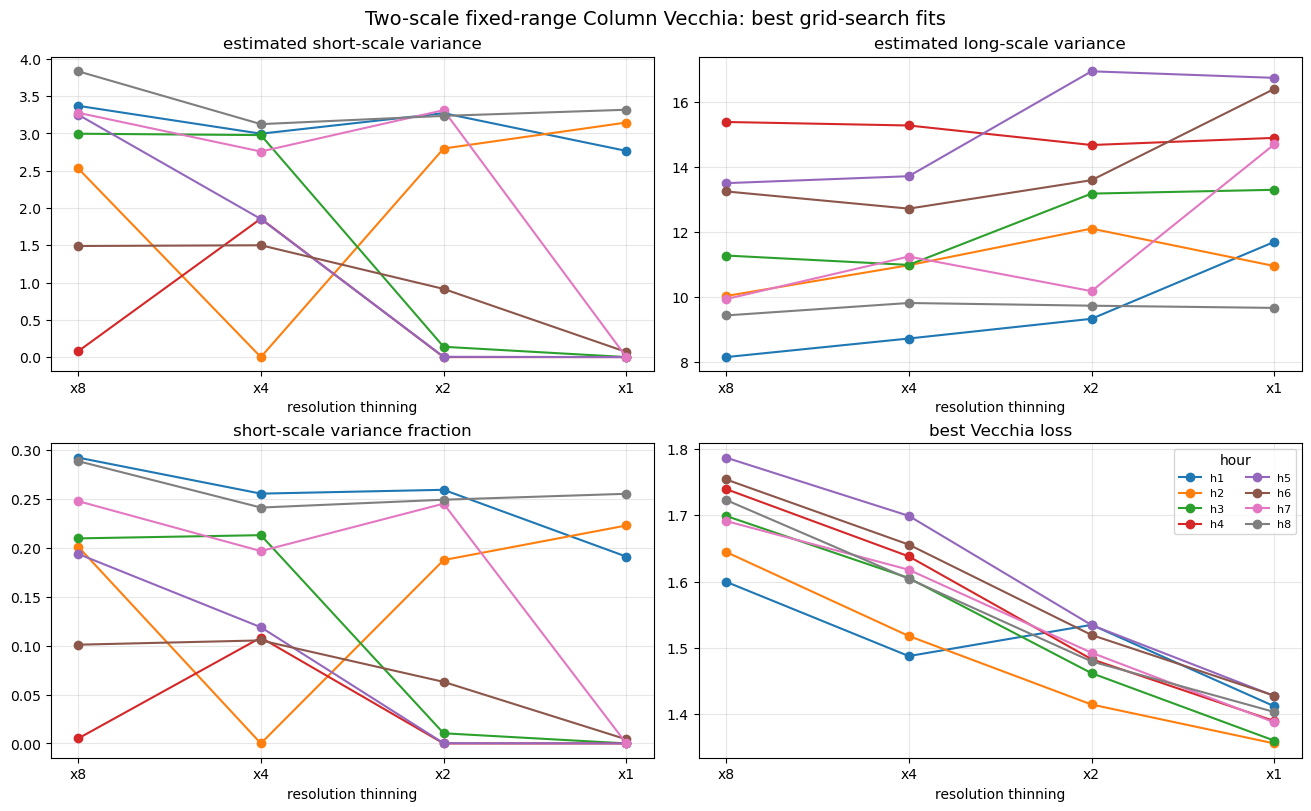

Saved: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_multiscale_column_rangegrid_sep3_nug2_050826_best_range_pair_trajectories.png


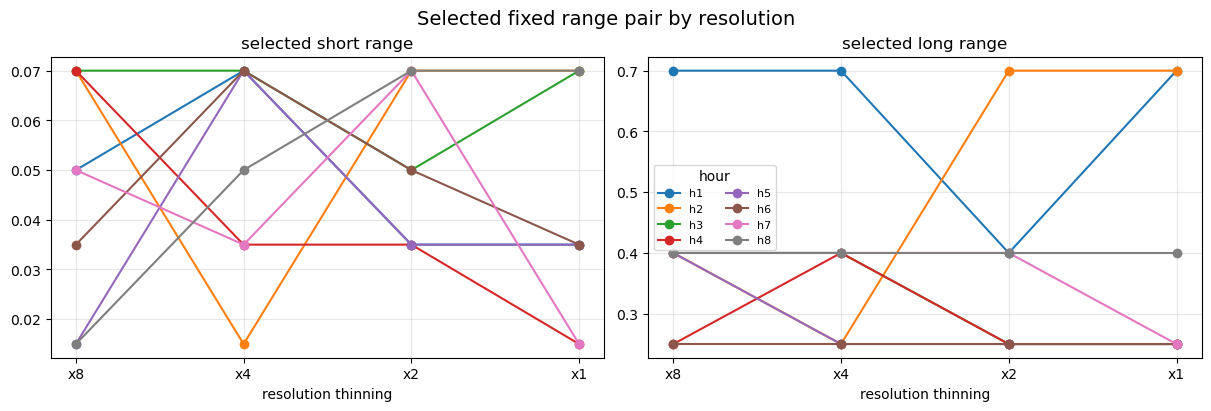

In [11]:
# Plot best variance split and selected ranges across resolution.
plot_df = best_df.copy()
plot_df['resolution_label'] = pd.Categorical(
    plot_df['resolution_label'], categories=[f'x{s}' for s in RESOLUTION_STRIDES], ordered=True
)
plot_df = plot_df.sort_values(['hour_idx', 'resolution_label'])

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
plot_specs = [
    ('est_sigmasq_short', 'estimated short-scale variance'),
    ('est_sigmasq_long', 'estimated long-scale variance'),
    ('est_short_fraction', 'short-scale variance fraction'),
    ('loss', 'best Vecchia loss'),
]
for ax, (col, title) in zip(axes.ravel(), plot_specs):
    for hour_idx, sub in plot_df.groupby('hour_idx'):
        ax.plot(sub['resolution_label'].astype(str), sub[col], marker='o', linewidth=1.5, label=f'h{int(hour_idx)+1}')
    ax.set_title(title)
    ax.set_xlabel('resolution thinning')
    ax.grid(True, alpha=0.3)
axes.ravel()[-1].legend(ncol=2, fontsize=8, title='hour')
fig.suptitle('Two-scale fixed-range Column Vecchia: best grid-search fits', fontsize=14)
plot_path = OUT_DIR / f'{OUT_PREFIX}_best_variance_trajectories.png'
fig.savefig(plot_path, dpi=180, bbox_inches='tight')
print('Saved:', plot_path)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for ax, col, title in [
    (axes[0], 'range_short_fixed', 'selected short range'),
    (axes[1], 'range_long_fixed', 'selected long range'),
]:
    for hour_idx, sub in plot_df.groupby('hour_idx'):
        ax.plot(sub['resolution_label'].astype(str), sub[col], marker='o', linewidth=1.5, label=f'h{int(hour_idx)+1}')
    ax.set_title(title)
    ax.set_xlabel('resolution thinning')
    ax.grid(True, alpha=0.3)
axes[-1].legend(ncol=2, fontsize=8, title='hour')
fig.suptitle('Selected fixed range pair by resolution', fontsize=14)
range_plot_path = OUT_DIR / f'{OUT_PREFIX}_best_range_pair_trajectories.png'
fig.savefig(range_plot_path, dpi=180, bbox_inches='tight')
print('Saved:', range_plot_path)
plt.show()

In [13]:
# Optional: loss table for one hour/resolution to inspect the range grid surface.
INSPECT_HOUR_IDX = HOUR_IDX_LIST[0]
INSPECT_STRIDE = 1
surf = all_df[(all_df['hour_idx'] == INSPECT_HOUR_IDX) & (all_df['resolution_stride'] == INSPECT_STRIDE)].copy()
if len(surf):
    loss_pivot = surf.pivot(index='range_short_fixed', columns='range_long_fixed', values='loss')
    shortfrac_pivot = surf.pivot(index='range_short_fixed', columns='range_long_fixed', values='est_short_fraction')
    print(f'Loss surface: hour={INSPECT_HOUR_IDX + 1}, resolution=x{INSPECT_STRIDE}')
    display(round_df(loss_pivot))
    print('Short variance fraction surface')
    display(round_df(shortfrac_pivot))

Loss surface: hour=1, resolution=x1


range_long_fixed,0.15,0.25,0.40,0.70
range_short_fixed,,,,
0.015,1.4598,1.4342,1.4228,1.4205
0.025,1.4540,1.4290,1.4179,1.4149
0.035,1.4480,1.4245,1.4145,1.4119
0.050,NaN,1.4202,1.4126,1.4121
0.070,NaN,1.4176,1.4136,1.4169


Short variance fraction surface


range_long_fixed,0.15,0.25,0.40,0.70
range_short_fixed,,,,
0.015,0.0495,0.1124,0.1210,0.0972
0.025,0.0526,0.1386,0.1574,0.1354
0.035,0.0533,0.1687,0.2020,0.1912
0.050,NaN,0.2133,0.2692,0.2850
0.070,NaN,0.2724,0.3518,0.3877
